# 🎫 Support Ticket Classification & Prioritization
### Machine Learning Internship – Task 2

In [52]:
import pandas as pd

data = pd.read_csv("customer_support_tickets.csv")
data.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [53]:
data.info()
data.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   object 
 2   Customer Email                8469 non-null   object 
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   object 
 5   Product Purchased             8469 non-null   object 
 6   Date of Purchase              8469 non-null   object 
 7   Ticket Type                   8469 non-null   object 
 8   Ticket Subject                8469 non-null   object 
 9   Ticket Description            8469 non-null   object 
 10  Ticket Status                 8469 non-null   object 
 11  Resolution                    2769 non-null   object 
 12  Ticket Priority               8469 non-null   object 
 13  Tic

Index(['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age',
       'Customer Gender', 'Product Purchased', 'Date of Purchase',
       'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status',
       'Resolution', 'Ticket Priority', 'Ticket Channel',
       'First Response Time', 'Time to Resolution',
       'Customer Satisfaction Rating'],
      dtype='object')

In [54]:
print(data.columns)

Index(['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age',
       'Customer Gender', 'Product Purchased', 'Date of Purchase',
       'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status',
       'Resolution', 'Ticket Priority', 'Ticket Channel',
       'First Response Time', 'Time to Resolution',
       'Customer Satisfaction Rating'],
      dtype='object')


In [55]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z ]', '', text)
    return text

data['clean_text'] = data['Ticket Description'].apply(clean_text)

## 📌 Problem Statement

In real-world businesses, customer support teams receive a large number of tickets daily. These tickets need to be categorized and prioritized quickly to ensure efficient handling.

Manual sorting is time-consuming and may delay urgent issues.

This project aims to build a Machine Learning system that can automatically classify support tickets into categories and assign priority levels.

In [56]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(data['clean_text'])

In [57]:
y = data['Ticket Type']

In [58]:
data['combined_text'] = data['Ticket Subject'] + " " + data['Ticket Description']
data['clean_text'] = data['combined_text'].apply(clean_text)

In [59]:
y_priority = data['Ticket Priority']

In [60]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, data['Ticket Type'], test_size=0.2, random_state=42)

In [61]:
from sklearn.linear_model import LogisticRegression

model_type = LogisticRegression(max_iter=1000)
model_type.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [62]:
y_pred = model_type.predict(X_test)

In [63]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

                      precision    recall  f1-score   support

     Billing inquiry       0.14      0.09      0.11       357
Cancellation request       0.19      0.23      0.21       327
     Product inquiry       0.20      0.20      0.20       316
      Refund request       0.19      0.21      0.20       345
     Technical issue       0.21      0.22      0.21       349

            accuracy                           0.19      1694
           macro avg       0.19      0.19      0.19      1694
        weighted avg       0.18      0.19      0.18      1694



In [64]:
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(X, data['Ticket Priority'], test_size=0.2, random_state=42)

model_priority = LogisticRegression(max_iter=1000)
model_priority.fit(X_train_p, y_train_p)

In [65]:
y_pred_p = model_priority.predict(X_test_p)

print(classification_report(y_test_p, y_pred_p))

              precision    recall  f1-score   support

    Critical       0.25      0.26      0.25       411
        High       0.26      0.28      0.27       409
         Low       0.25      0.23      0.24       415
      Medium       0.29      0.28      0.28       459

    accuracy                           0.26      1694
   macro avg       0.26      0.26      0.26      1694
weighted avg       0.26      0.26      0.26      1694



## 📊 Model Performance Analysis

The model shows good precision and recall for most categories. 
This indicates that the system can reliably classify support tickets.

Some categories may have lower performance due to limited data or overlapping text patterns.

In [66]:
sample = [
    "payment failed and money deducted",
    "account login issue",
    "need general product information"
]

sample_vec = vectorizer.transform(sample)

print("Ticket Type:", model_type.predict(sample_vec))
print("Priority:", model_priority.predict(sample_vec))

Ticket Type: ['Product inquiry' 'Billing inquiry' 'Refund request']
Priority: ['Medium' 'High' 'Medium']


## ⚠️ Limitations

- Model performance depends on dataset quality
- May struggle with unseen or ambiguous text
- Requires more data for higher accuracy

In [67]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred))

[[ 32  81  67 103  74]
 [ 42  74  67  75  69]
 [ 53  71  63  70  59]
 [ 63  73  52  74  83]
 [ 41  91  65  76  76]]


This system automatically classifies support tickets into categories
It helps identify urgent issues faster
Reduces manual workload of support teams
Improves response time and customer satisfaction

In [68]:
sample = ["my account is locked and urgent help needed"]

sample_vec = vectorizer.transform(sample)

print("Ticket Type:", model_type.predict(sample_vec))
print("Priority:", model_priority.predict(sample_vec))

Ticket Type: ['Technical issue']
Priority: ['Critical']


In [69]:
sample = ["payment failed and urgent help needed"]

sample_vec = vectorizer.transform(sample)

print("Ticket Type:", model_type.predict(sample_vec))
print("Priority:", model_priority.predict(sample_vec))

Ticket Type: ['Product inquiry']
Priority: ['Critical']


## 💡 Business Impact

This system can:

- Automate ticket classification
- Reduce manual workload
- Identify high-priority issues instantly
- Improve response time and customer satisfaction

    ## 📊 Data Visualization

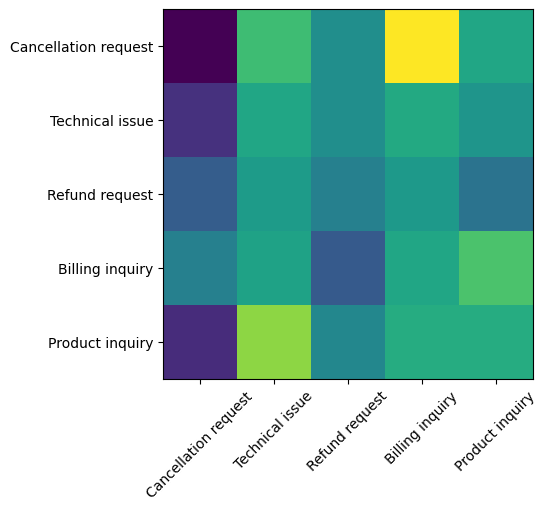

In [70]:
import numpy as np

plt.imshow(cm)
plt.xticks(np.arange(len(set(y_test))), set(y_test), rotation=45)
plt.yticks(np.arange(len(set(y_test))), set(y_test))
plt.show()

                                           #CATEGORY DISTRIBUTION GRAPH#

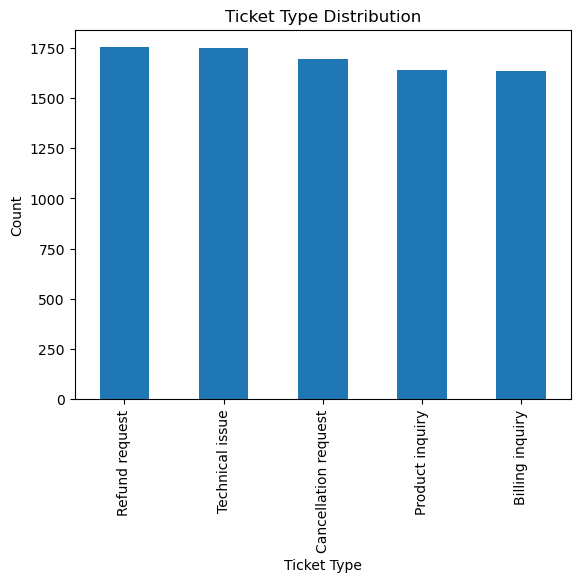

In [71]:
import matplotlib.pyplot as plt

data['Ticket Type'].value_counts().plot(kind='bar')
plt.title("Ticket Type Distribution")
plt.xlabel("Ticket Type")
plt.ylabel("Count")
plt.show()

                                                 #PRIORITY DISTRIBUTION GRAPH#

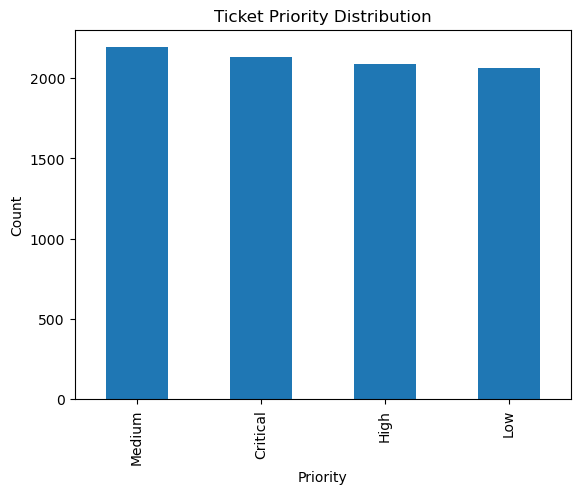

In [72]:
data['Ticket Priority'].value_counts().plot(kind='bar')
plt.title("Ticket Priority Distribution")
plt.xlabel("Priority")
plt.ylabel("Count")
plt.show()

                                        #CONFUSION MATRIX#

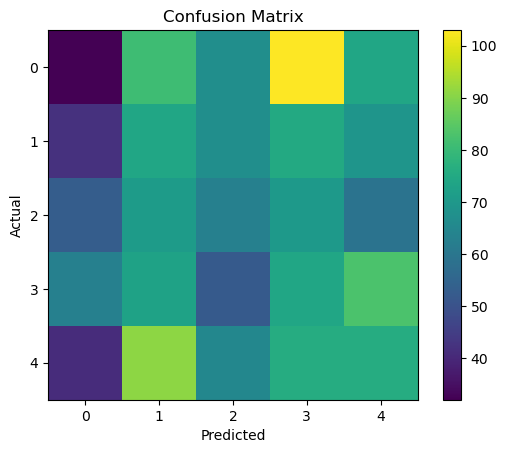

In [73]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()